# Kaartdetail van bezorgzones verminderen voor snelle logistieke dashboards met PROC GREDUCE

## Samenvatting

Een regionale pakketvervoerder slaat de grenzen van zijn servicegebieden op als dichte veelhoekcontouren, waardoor routeplanningsdashboards ze traag opnieuw tekenen. Deze notebook genereert de grenscoördinaten voor vier bezorgzones, gebruikt **PROC GREDUCE** om elk grenspunt te voorzien van een `DENSITY`-niveau, en tekent vervolgens een choropleetkaart van de tijdige levering met **PROC GMAP** op een verminderd detailniveau, zodat de kaart sneller tekent terwijl elke zone herkenbaar blijft.

GREDUCE verdeelde de 96 grenspunten in drie niveaus: 10 punten op `DENSITY=0`, 44 op `DENSITY=2` en 42 op `DENSITY=3`. Door alleen het grove niveau te behouden (`DENSITY <= 2`) daalt de kaart van 96 naar 54 hoekpunten — ongeveer 44% reductie — terwijl de vier zones duidelijk herkenbaar blijven in de vergelijking hieronder.

## Gegevensbronnen

Alle gegevens worden inline gegenereerd door de onderstaande DATA-stappen — geen externe bestanden of netwerktoegang.

| Dataset | Rijen | Belangrijkste variabelen | Beschrijving |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zones x 24 hoekpunten) | `zone` (ID), `x`, `y` | Synthetische gesloten-veelhoek grenscoördinaten voor vier bezorgservicezones, elk een verspringende ellips getraceerd met 24 hoekpunten, zodat dichtheidsreductie iets heeft om te verdunnen. |
| `reducedmap` | 96 | voegt `density` toe | Uitvoer van PROC GREDUCE: de grenspunten voorzien van een `DENSITY`-niveau (hier 0, 2 of 3) voor selectieve weergave. |
| `coarsemap` | 54 | subset van `reducedmap` | De `DENSITY <= 2`-subset — het grove, snel te renderen niveau voor de dashboardkaart met verminderd detail. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Eén responsrij per zone: synthetisch percentage tijdige levering en dagelijks pakketvolume, gekoppeld aan de kaart voor de choropleet. |

> **Opmerking over steekproefgrootte.** Deze omgeving draait ongelicentieerd, dus elke DATA-stap is beperkt tot 100 uitvoerobservaties. De kaart is gedimensioneerd op 4 zones x 24 hoekpunten = 96 punten, zodat het volledige gebied binnen die limiet past; een gelicentieerde installatie zou honderden hoekpunten per zone traceren, waar GREDUCE nog meer voordeel oplevert.

# Kaartdetail van bezorgzones verminderen met PROC GREDUCE

Logistieke operators visualiseren prestaties op kaarten van hun **servicegebieden** — de geografische zones waarvoor een depot verantwoordelijk is. Die zonegrenzen worden vaak vastgelegd op landmeetkundige resolutie: veel hoekpunten per veelhoek. Wanneer een routeplanningsdashboard meerdere zones tegelijk opnieuw tekent, maakt al dat hoekpuntdetail het renderen traag zonder extra beslissingswaarde op dashboardzoom.

**PROC GREDUCE** pakt dit aan. Het onderzoekt elke veelhoek en voorziet elk grenspunt van een `DENSITY`-niveau, waarbij 0 de punten markeert die de essentiële vorm bepalen en hogere niveaus geleidelijk fijner detail markeren. Verderop selecteer je een niveau met `WHERE density <= n` om een kaart met verminderd detail te tekenen die snel tekent terwijl elke zone herkenbaar blijft.

In deze notebook:
1. Genereren we grenscontouren voor vier bezorgzones.
2. Voeren we PROC GREDUCE uit om `DENSITY`-niveaus toe te wijzen.
3. Onderzoeken we hoe de punten verdeeld zijn over de dichtheidsniveaus.
4. Tekenen we choropleetkaarten met volledig en verminderd detail van tijdige levering en vergelijken we ze.

## Stap 1 — Genereer de kaart met zonegrenzen

Een SAS-kaartdataset heeft één observatie per **grenspunt**, met een `ID`-variabele die het gebied benoemt en numerieke `x`/`y`-coördinaten. We tekenen elke bezorgzone als een verspringende ellips met 24 gelijkmatig verdeelde hoeken, zodat de veelhoeken redelijk dicht beginnen en reductie iets heeft om mee te werken.

`call streaminit` legt de random-reeks vast voor reproduceerbaarheid, en `rand('uniform')` voegt kleine onregelmatigheden toe aan de grens, zodat de contouren lezen als opgemeten gebieden in plaats van perfecte ellipsen.

In [1]:
GEGEVENS zonemap;
    CALL streaminit(20260531);
    /* Vier bezorgzones, elk een verspringende ellips van 24 hoekpunten.
       cx/cy = zonecentrum, rx/ry = nominale radii (gebiedsgrootte). */
    REEKS cx[4] _temporary_ (12 32 20 40);
    REEKS cy[4] _temporary_ (30 32 14 16);
    REEKS rx[4] _temporary_ ( 8  9  6  7);
    REEKS ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 hoekpunten (0..23) per contour */
    DOE zone = 1 TOT 4;
        DOE i = 0 TOT nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radiale ruis: +/- ~6% onregelmatige kustlijn-achtige rand */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            UITVOER;
        EINDE;
    EINDE;
    BEWAREN zone x y;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=zonemap n MIN MAX nmiss;
    KLASSE zone;
    VARIABELE x y;
    label zone="Zone" x="X-coördinaat" y="Y-coördinaat";
UITVOEREN;

                                                  The MEANS Procedure

                                          Analysis Variable : x X-coördinaat

        Zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                          Analysis Variable : y Y-coördinaat

        Zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
  


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


De PROC MEANS-tabel bevestigt de synthetische geometrie: vier zones, elk met precies 24 grenspunten binnen redelijke `x`/`y`-bereiken en geen ontbrekende coördinaten. De vier ellipsen bezetten niet-overlappende gebieden (zone 1 rond x=12, zone 2 rond x=32, zones 3 en 4 lager), zodat de choropleet vier duidelijk onderscheiden gebieden toont. Dit zijn de contouren die PROC GREDUCE zal verdunnen.

## Stap 2 — DENSITY-niveaus toewijzen met PROC GREDUCE

De `ID`-instructie noemt de variabele die elk gebied definieert — hier `zone`. PROC GREDUCE evalueert de veelhoek van elke zone afzonderlijk (met Douglas-Peucker-achtige vereenvoudiging) en schrijft de invoerdataset terug met een toegevoegde integer-variabele `density`: niveau 0 markeert de weinige punten die de essentiële vorm verankeren, en hogere niveaus markeren geleidelijk fijner detail dat je als eerste kunt laten vallen.

We laten GREDUCE zijn eigen drempels afleiden uit de data in plaats van vaste niveaugroottes op te leggen, en inspecteren vervolgens de resulterende verdeling.

                                        Grenspunten behouden per DENSITY-niveau                                         

                                                   The FREQ Procedure

Dichtheid (DENSITY)    Frequency    Percent
--------------------------------------------
0                             10     10.42
2                             44     45.83
3                             42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


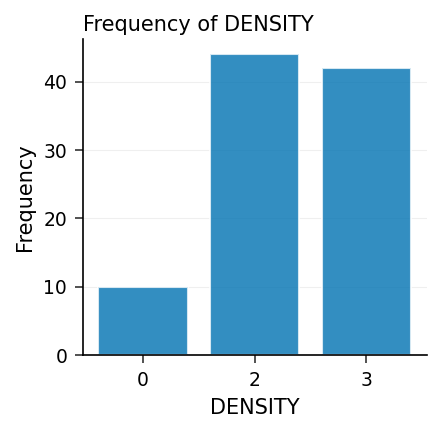

In [2]:
PROCEDURE GREDUCE GEGEVENS=zonemap out=reducedmap;
    id zone;
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=reducedmap;
    TABLES DENSITY / nocum;
    TITEL 'Grenspunten behouden per DENSITY-niveau';
    label DENSITY="Dichtheid (DENSITY)";
UITVOEREN;

## Stap 3 — De dichtheidsniveaus inspecteren

De frequentietabel toont hoe GREDUCE de 96 grenspunten heeft ingedeeld:

| DENSITY | Punten | Aandeel |
|---------|--------|-------|
| 0 | 10 | 10,4% |
| 2 | 44 | 45,8% |
| 3 | 42 | 43,8% |

Slechts 10 punten hebben het laagste niveau (de essentiële-vorm-ankers), terwijl de resterende 86 verdeeld zijn over niveaus 2 en 3. Voor een dashboardniveau behouden we alles op `DENSITY <= 2`: dat behoudt 54 van de 96 punten en laat de 42 fijnste-detail-hoekpunten (`DENSITY=3`) vallen. De PROC MEANS hieronder bevestigt dat het grove niveau 13–14 hoekpunten per zone bevat in plaats van de oorspronkelijke 24.

In [3]:
PROCEDURE GEMIDDELDEN GEGEVENS=reducedmap n;
    KLASSE zone;
    WAAR DENSITY <= 2;
    VARIABELE x;
    TITEL 'Hoekpunten behouden per zone op dashboarddetail (DENSITY <= 2)';
    label zone="Zone" x="X-coördinaat";
UITVOEREN;

                             Hoekpunten behouden per zone op dashboarddetail (DENSITY <= 2)                             

                                                  The MEANS Procedure

                                          Analysis Variable : X X-coördinaat

        Zone              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 4 — De grove kaart en de prestatierespons per zone opbouwen

We materialiseren het dashboardniveau als `coarsemap` (`DENSITY <= 2`), zodat PROC GMAP de verminderde contour direct kan tekenen. We genereren ook één KPI-rij per zone — een **percentage tijdige levering** en een **dagelijks pakketvolume** — gesleuteld op `zone` zodat GMAP elk gebied kan inkleuren.

In [4]:
GEGEVENS coarsemap;
    INSTELLEN reducedmap;
    WAAR DENSITY <= 2;
UITVOEREN;

GEGEVENS zonekpi;
    CALL streaminit(771);
    DOE zone = 1 TOT 4;
        /* percentage tijdige levering rond 92%, realistische spreiding */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        UITVOER;
    EINDE;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=zonekpi noobs;
    TITEL "Synthetische bezorg-KPI's per zone";
    label zone="Zone" ontime_rate="Tijdige levering (%)" parcels="Pakketten";
UITVOEREN;

                                           Synthetische bezorg-KPI's per zone                                           

Zone  Tijdige levering (%)  Pakketten
   1                  92.6       4704
   2                  95.6       2932
   3                  93.4       2934
   4                  94.6       2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


De vier synthetische percentages tijdige levering liggen tussen 92,6% en 95,6%, met dagelijkse pakketvolumes van ongeveer 2.500 tot 4.700. Zone 2 presteert het best met 95,6%; zone 1 het zwakst met 92,6%. Dit zijn de waarden die de kleurbanden van de choropleet coderen.

## Stap 5 — Choropleetkaarten met volledig en verminderd detail tekenen

We tekenen dezelfde choropleet van tijdige levering twee keer: één keer vanuit de volledige `reducedmap` met 96 hoekpunten en één keer vanuit `coarsemap` met 54 hoekpunten. `MAP=` levert de grenzen, `DATA=` de KPI-respons, en beide delen de `zone`-ID. De `CHORO`-instructie kleurt elke zone in op basis van `ontime_rate` met `LEVELS=4` kleurbanden en `COUTLINE=` voor scherpe randen. Het vergelijken van de twee kaarten toont wat de reductie visueel kost.

                                            Volledig detail: 96 grenspunten                                             




NOTE: Option TITLE changed to Volledig detail: 96 grenspunten.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Tijdige levering (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds


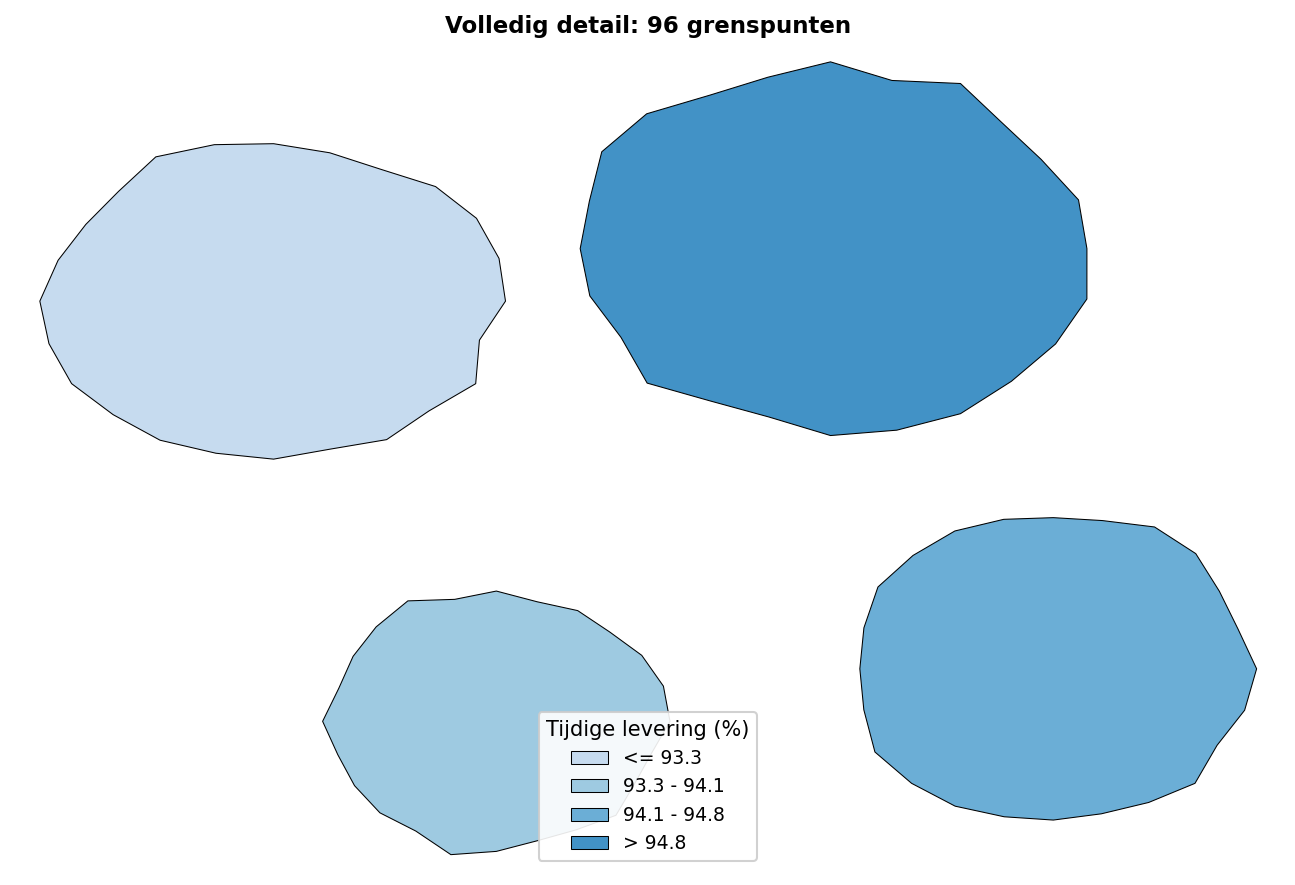

In [5]:
TITEL 'Volledig detail: 96 grenspunten';
PROCEDURE GMAP map=reducedmap GEGEVENS=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
    label ontime_rate="Tijdige levering (%)" zone="Zone";
UITVOEREN;

                                    Verminderd detail: 54 hoekpunten (DENSITY <= 2)                                     




NOTE: Option TITLE changed to Verminderd detail: 54 hoekpunten (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Tijdige levering (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.45 seconds
  cpu   0.45 seconds


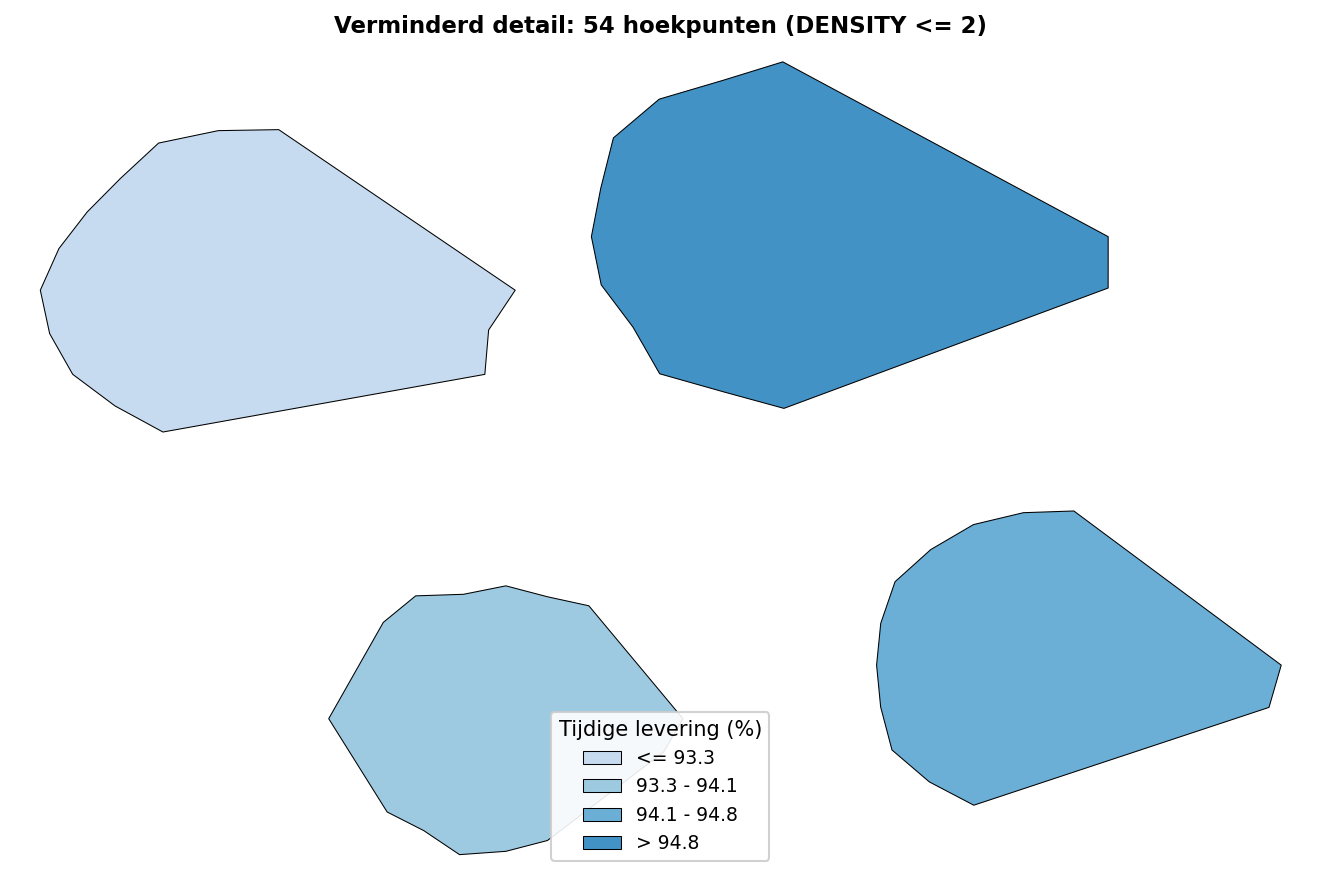

In [6]:
TITEL 'Verminderd detail: 54 hoekpunten (DENSITY <= 2)';
PROCEDURE GMAP map=coarsemap GEGEVENS=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
    label ontime_rate="Tijdige levering (%)" zone="Zone";
UITVOEREN;

## De resultaten interpreteren

PROC GREDUCE zette elke contour van 24 hoekpunten per zone om in een gegradeerde reeks grenspunten (niveaus 0, 2 en 3 in deze uitvoering). Door het `DENSITY <= 2`-niveau te selecteren, daalde de kaart van 96 naar 54 hoekpunten — een reductie van 44% in de punten die de renderer moet tekenen — toch bevestigen de choropleetkaarten naast elkaar dat de vier zones duidelijk herkenbaar blijven: de contouren van de verminderde kaart zijn zichtbaar hoekiger, maar elk gebied behoudt zijn positie, grootte en kleurband, zodat een operator hetzelfde scorebord op beide manieren leest.

Dat scorebord rangschikt de zones op percentage tijdige levering: zone 2 gaat aan kop met 95,6% (donkerste band), zones 3 en 4 zitten in de middenmoot rond 93–95%, en zone 1 sluit de rij met 92,6% (lichtste band) — het gebied dat een planner als eerste zou onderzoeken voor routerings- of depotcapaciteitsproblemen.

Omdat de reductie niet-destructief is — de punten met volledig detail blijven bestaan in `reducedmap` — ondersteunt dezelfde dataset zowel de snelle dashboardweergave (`DENSITY <= 2`) als een hoge-resolutie afdruk- of auditweergave (`DENSITY <= 3`, of de volledige set) door één `WHERE`-drempel te wijzigen, zonder de geometrie opnieuw te hoeven importeren of reduceren.